# Merged `SmoothGrad` verifying it returns equal values to the non-merged SmoothGrad 

One `SmoothGrad` class, three model types.

The last cell checks equality.

## Disable the runtime type checks (optional)

**Must run before anything imports `jaxtyping`** — the flag is read at import time, so this
has to be the first cell executed in a fresh kernel. Comment it out to get the shape checks
back; do that before believing any actual attribution numbers, since with the checks off a
shape bug surfaces as a downstream broadcast error or not at all.

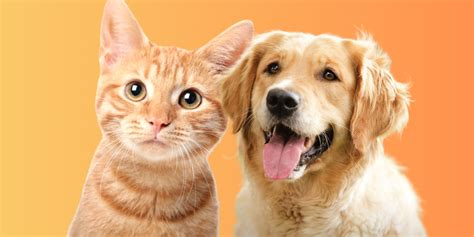

In [1]:
%matplotlib inline

import torch
from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForCausalLM,
    AutoModelForImageClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

from interpreto.attributions.methods.old_image_smooth_grad import ImageSmoothGrad as LegacyImageSmoothGrad
from interpreto.attributions.methods.old_smooth_grad import SmoothGrad as LegacySmoothGrad
from interpreto.attributions.methods.smooth_grad import SmoothGrad
from interpreto.visualizations import plot_attributions, plot_image_attribution

sentence = "interpreto is nice"
image = Image.open("../fixtures/images/equal_cat_and_dog.jpg").convert("RGB")
image

## The three models

In [2]:
cls_model = AutoModelForSequenceClassification.from_pretrained("hf-internal-testing/tiny-random-bert")
cls_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-bert")

gen_model = AutoModelForCausalLM.from_pretrained("hf-internal-testing/tiny-random-gpt2")
gen_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-gpt2")

vit_model = AutoModelForImageClassification.from_pretrained("akahana/vit-base-cats-vs-dogs")
vit_processor = AutoImageProcessor.from_pretrained("akahana/vit-base-cats-vs-dogs")

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: hf-internal-testing/tiny-random-bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
qa_outputs.weight                          | UNEXPECTED |  | 
qa_outputs.bias                            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

## The three explainers



In [3]:
cls_explainer = SmoothGrad(
    cls_model,
    cls_processor,
)

gen_explainer = SmoothGrad(
    gen_model,
    gen_processor,
)

vit_explainer = SmoothGrad(
    vit_model,
    vit_processor,
)

legacy_cls_explainer = LegacySmoothGrad(cls_model, cls_processor)
legacy_gen_explainer = LegacySmoothGrad(gen_model, gen_processor)
legacy_vit_explainer = LegacyImageSmoothGrad(vit_model, vit_processor)

vit_explainer = SmoothGrad(vit_model, vit_processor)

torch.manual_seed(0)
legacy_cls_outputs = legacy_cls_explainer.explain(sentence)
torch.manual_seed(0)
legacy_gen_outputs = legacy_gen_explainer.explain(sentence, targets="right")
torch.manual_seed(0)
legacy_vit_outputs = legacy_vit_explainer.explain(image)

torch.manual_seed(0)
vit_outputs = vit_explainer.explain(image)
torch.manual_seed(0)
cls_outputs = cls_explainer.explain(sentence)
torch.manual_seed(0)
gen_outputs = gen_explainer.explain(sentence, targets="right")

## Checking that the new methods are equal to the old

We consider here that LegacySmoothGrad (on all task / modalities combination) is the ground truth. We want to show that the merged SmoothGrad method returns the same AttributionOutput / ImageAttributionOutput as the ""Legacy""SmoothGrad

In [4]:
def same(a, b):
    """Exact equality, counting NaN in the same position as a match."""
    return a.shape == b.shape and bool(((a == b) | (a.isnan() & b.isnan())).all())


for name, new, old in [
    ("cls", cls_outputs[0], legacy_cls_outputs[0]),
    ("gen", gen_outputs[0], legacy_gen_outputs[0]),
    ("vit", vit_outputs[0], legacy_vit_outputs[0]),
]:
    ok = same(new.attributions, old.attributions)
    print(f"{name}: {tuple(new.attributions.shape)}  {'identical' if ok else 'DIFFERENT'}")
    assert ok, f"{name}: merged attributions differ from legacy"

print("\nmerged SmoothGrad reproduces the legacy attributions exactly")

cls: (1, 3)  identical
gen: (1, 4)  identical
vit: (1, 50176)  identical

merged SmoothGrad reproduces the legacy attributions exactly


## Visualize



In [5]:
plot_attributions(cls_outputs[0])

In [6]:
plot_attributions(gen_outputs[0])

In [7]:
plot_attributions(legacy_gen_outputs[0])

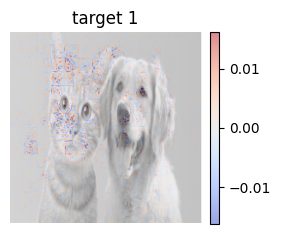

In [8]:
fig, axes = plot_image_attribution(vit_outputs, alpha=0.5)